In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.stats import spearmanr, pearsonr

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42


ANALYSIS_START = pd.Timestamp("2025-08-01")
ANALYSIS_END = pd.Timestamp("2025-11-01")


MIN_DISTRICT_ORDERS_FOR_RANKING = 200

def find_file(*filenames):
    for filename in filenames:
        for p in [
            Path(filename),
            Path.cwd() / filename,
            Path("/mnt/data") / filename
        ]:
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {filenames}")

details_path = find_file("order_details.csv", "order_details(3).csv")
timestamps_path = find_file("order_timestamp.csv", "order_timestamp(3).csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details:", details.shape)
print("order_timestamp:", timestamps.shape)


order_details: (151803, 10)
order_timestamp: (151803, 4)


In [2]:
for col in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[col] = pd.to_datetime(
        timestamps[col],
        errors="coerce"
    )

details["created_date"] = pd.to_datetime(
    details["created_date"],
    errors="coerce"
)

df = details.merge(
    timestamps[
        [
            "order_id",
            "start_time_slot",
            "accept_time",
            "arrived_pickup_at"
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

df = df[
    (df["start_time_slot"] >= ANALYSIS_START)
    & (df["start_time_slot"] < ANALYSIS_END)
].copy()

df = df.reset_index(drop=True)

print(f"Rows in Aug–Oct analysis period: {len(df):,}")
print(f"Unique orders: {df['order_id'].nunique():,}")


Rows in Aug–Oct analysis period: 151,580
Unique orders: 151,580


In [3]:
df["BATR_raw_min"] = (
    df["arrived_pickup_at"]
    - df["start_time_slot"]
).dt.total_seconds() / 60

df["Acceptance_raw_min"] = (
    df["accept_time"]
    - df["start_time_slot"]
).dt.total_seconds() / 60

df["Arrival_raw_min"] = (
    df["arrived_pickup_at"]
    - df["accept_time"]
).dt.total_seconds() / 60



df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)
df["Acceptance_min"] = df["Acceptance_raw_min"].clip(lower=0)
df["Arrival_min"] = df["Arrival_raw_min"].clip(lower=0)

df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)


df["timing_complete"] = (
    df["start_time_slot"].notna()
    & df["accept_time"].notna()
    & df["arrived_pickup_at"].notna()
)

df["sequential_timing"] = (
    df["timing_complete"]
    & (df["accept_time"] >= df["start_time_slot"])
    & (df["arrived_pickup_at"] >= df["accept_time"])
)

df["arrived_before_accept"] = (
    df["timing_complete"]
    & (df["arrived_pickup_at"] < df["accept_time"])
)


seq = df[
    df["sequential_timing"]
    & df["BATR15"].notna()
].copy()

seq["BATR_component_sum"] = (
    seq["Acceptance_min"]
    + seq["Arrival_min"]
)

seq["identity_error"] = (
    seq["BATR_min"]
    - seq["BATR_component_sum"]
)

print(f"Valid BATR labels: {df['BATR15'].notna().sum():,}")
print(f"Sequential timing cohort: {len(seq):,}")
print(
    "Arrived-before-accept cohort:",
    f"{df['arrived_before_accept'].sum():,}",
    f"({df['arrived_before_accept'].mean()*100:.2f}%)"
)
print(
    "Maximum additive identity error in sequential cohort:",
    seq["identity_error"].abs().max()
)


Valid BATR labels: 151,580
Sequential timing cohort: 127,774
Arrived-before-accept cohort: 23,803 (15.70%)
Maximum additive identity error in sequential cohort: 0.0


In [4]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Orders in period",
        "Valid BATR",
        "Sequential timing",
        "Arrived before accept",
        "Missing start time",
        "Missing accept time",
        "Missing arrival time"
    ],
    "Count": [
        len(df),
        df["BATR15"].notna().sum(),
        df["sequential_timing"].sum(),
        df["arrived_before_accept"].sum(),
        df["start_time_slot"].isna().sum(),
        df["accept_time"].isna().sum(),
        df["arrived_pickup_at"].isna().sum()
    ]
})

quality_summary["Share of period (%)"] = (
    quality_summary["Count"] / len(df) * 100
)

display(quality_summary)


,Metric,Count,Share of period (%)
0,Orders in period,151580,100.000
1,Valid BATR,151580,100.000
2,Sequential timing,127774,84.295
3,Arrived before accept,23803,15.703
4,Missing start time,0,0.000
5,Missing accept time,3,0.002
6,Missing arrival time,0,0.000


In [5]:
timing_by_district = (
    df.groupby(["order_city", "district"])
      .agg(
          Orders=("order_id", "count"),
          Sequential=("sequential_timing", "sum"),
          Arrived_Before_Accept=("arrived_before_accept", "sum")
      )
      .reset_index()
)

timing_by_district["Sequential Coverage (%)"] = (
    timing_by_district["Sequential"]
    / timing_by_district["Orders"]
    * 100
)

timing_by_district["Arrived Before Accept (%)"] = (
    timing_by_district["Arrived_Before_Accept"]
    / timing_by_district["Orders"]
    * 100
)

display(
    timing_by_district.sort_values(
        "Sequential Coverage (%)"
    )
)


,order_city,district,Orders,Sequential,Arrived_Before_Accept,Sequential Coverage (%),Arrived Before Accept (%)
0,B,3720,9460,6154,3305,65.053,34.937
1,B,3724,3451,2266,1185,65.662,34.338
5,B,3752,65,47,18,72.308,27.692
3,B,3732,2181,1590,591,72.902,27.098
4,B,3740,4543,3352,1191,73.784,26.216
19,K,4532,4797,3656,1141,76.214,23.786
28,U,1420,12031,9641,2390,80.135,19.865
24,U,1404,4016,3319,697,82.644,17.356
14,K,1508,8887,7479,1408,84.157,15.843
2,B,3728,1624,1367,256,84.175,15.764


In [6]:
valid_batr = df[df["BATR15"].notna()].copy()
valid_batr["BATR15"] = valid_batr["BATR15"].astype(int)

overall_batr15 = valid_batr["BATR15"].mean() * 100

city_batr = (
    valid_batr.groupby("order_city")
    .agg(
        Orders=("order_id", "count"),
        Late_Orders=("BATR15", lambda s: (s == 0).sum()),
        BATR15_Rate=("BATR15", "mean"),
        BATR_Mean=("BATR_min", "mean"),
        BATR_Median=("BATR_min", "median"),
        BATR_P90=("BATR_min", lambda s: s.quantile(.90)),
        BATR_P95=("BATR_min", lambda s: s.quantile(.95))
    )
    .reset_index()
)

city_batr["BATR15 (%)"] = city_batr["BATR15_Rate"] * 100
city_batr["Share of All Late Orders (%)"] = (
    city_batr["Late_Orders"]
    / city_batr["Late_Orders"].sum()
    * 100
)

print(f"Overall BATR15: {overall_batr15:.2f}%")
display(city_batr)


Overall BATR15: 77.45%


,order_city,Orders,Late_Orders,BATR15_Rate,BATR_Mean,BATR_Median,BATR_P90,BATR_P95,BATR15 (%),Share of All Late Orders (%)
0,B,21324,2066,0.903,5.600,2.000,15.000,21.000,90.311,6.045
1,K,78888,21753,0.724,12.091,8.000,25.000,32.000,72.425,63.646
2,U,51368,10359,0.798,9.668,6.000,21.000,29.000,79.834,30.309


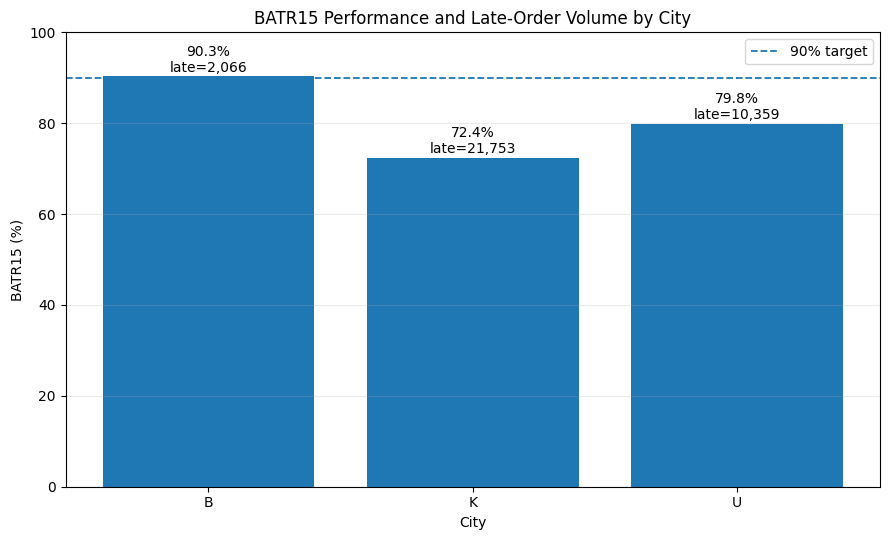

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    city_batr["order_city"],
    city_batr["BATR15 (%)"]
)

ax.axhline(
    90,
    linestyle="--",
    linewidth=1.3,
    label="90% target"
)

for i, row in city_batr.iterrows():
    ax.text(
        i,
        row["BATR15 (%)"] + 1,
        f"{row['BATR15 (%)']:.1f}%\n"
        f"late={int(row['Late_Orders']):,}",
        ha="center"
    )

ax.set_ylim(0, 100)
ax.set_title("BATR15 Performance and Late-Order Volume by City")
ax.set_xlabel("City")
ax.set_ylabel("BATR15 (%)")
ax.legend()
ax.grid(axis="y", alpha=.25)

plt.tight_layout()
plt.show()


In [8]:
district_batr = (
    valid_batr.groupby(["order_city", "district"])
    .agg(
        Orders=("order_id", "count"),
        Late_Orders=("BATR15", lambda s: (s == 0).sum()),
        BATR15_Rate=("BATR15", "mean"),
        BATR_Mean=("BATR_min", "mean"),
        BATR_Median=("BATR_min", "median"),
        BATR_P90=("BATR_min", lambda s: s.quantile(.90)),
        BATR_P95=("BATR_min", lambda s: s.quantile(.95))
    )
    .reset_index()
)

district_batr["BATR15 (%)"] = (
    district_batr["BATR15_Rate"] * 100
)

district_batr["Share of All Late Orders (%)"] = (
    district_batr["Late_Orders"]
    / district_batr["Late_Orders"].sum()
    * 100
)

district_batr = district_batr.sort_values(
    "Late_Orders",
    ascending=False
)

district_batr["Cumulative Late Share (%)"] = (
    district_batr["Share of All Late Orders (%)"]
    .cumsum()
)

display(
    district_batr[
        [
            "order_city",
            "district",
            "Orders",
            "Late_Orders",
            "BATR15 (%)",
            "BATR_P90",
            "Share of All Late Orders (%)",
            "Cumulative Late Share (%)"
        ]
    ]
)


,order_city,district,Orders,Late_Orders,BATR15 (%),BATR_P90,Share of All Late Orders (%),Cumulative Late Share (%)
9,K,1480,26893,8018,70.186,25.000,23.460,23.460
15,K,1512,10864,3367,69.008,26.000,9.851,33.311
17,K,1528,7115,2392,66.381,27.000,6.999,40.310
31,U,1432,13113,2374,81.896,20.000,6.946,47.256
30,U,1428,8576,1945,77.320,22.000,5.691,52.946
10,K,1484,5410,1750,67.652,27.000,5.120,58.067
14,K,1508,8887,1709,80.770,20.000,5.000,63.067
28,U,1420,12031,1685,85.995,18.000,4.930,67.997
23,U,1400,4162,1256,69.822,29.000,3.675,71.672
18,K,4176,4216,1187,71.845,33.500,3.473,75.145


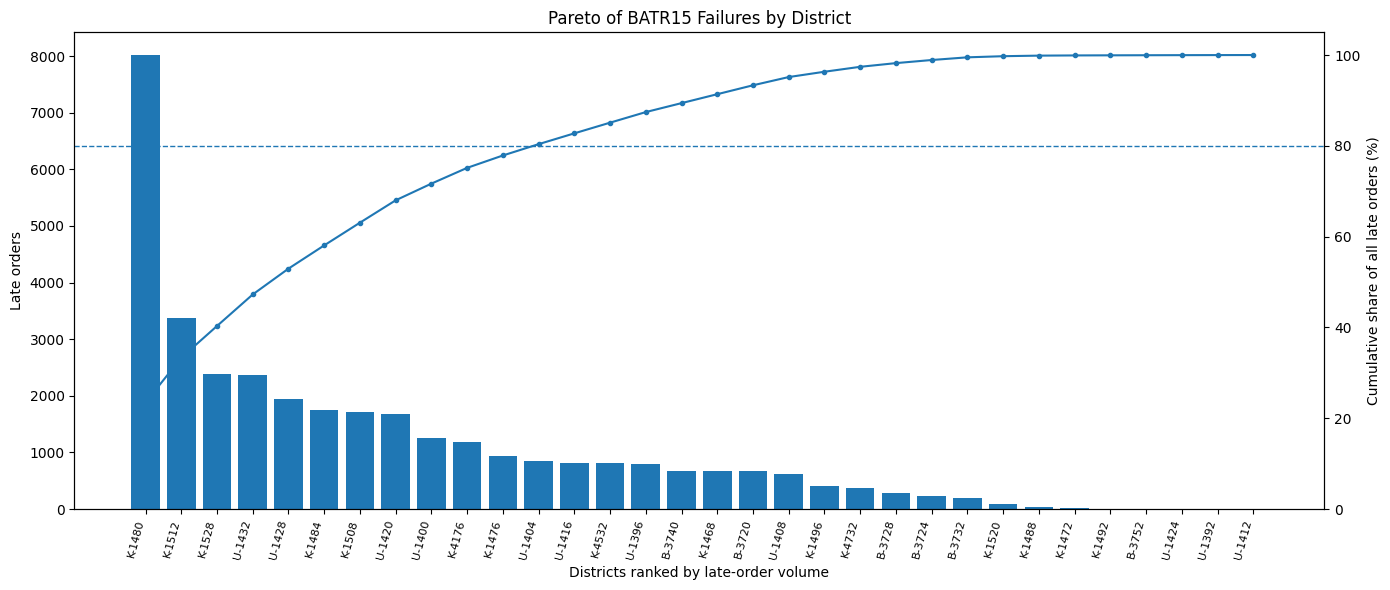

In [9]:
pareto = district_batr.reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(pareto))

ax1.bar(
    x,
    pareto["Late_Orders"]
)

ax1.set_ylabel("Late orders")
ax1.set_xlabel("Districts ranked by late-order volume")

labels = (
    pareto["order_city"].astype(str)
    + "-"
    + pareto["district"].astype(int).astype(str)
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    labels,
    rotation=75,
    ha="right",
    fontsize=8
)

ax2 = ax1.twinx()

ax2.plot(
    x,
    pareto["Cumulative Late Share (%)"],
    marker="o",
    markersize=3
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1
)

ax2.set_ylabel("Cumulative share of all late orders (%)")
ax2.set_ylim(0, 105)

ax1.set_title("Pareto of BATR15 Failures by District")

plt.tight_layout()
plt.show()


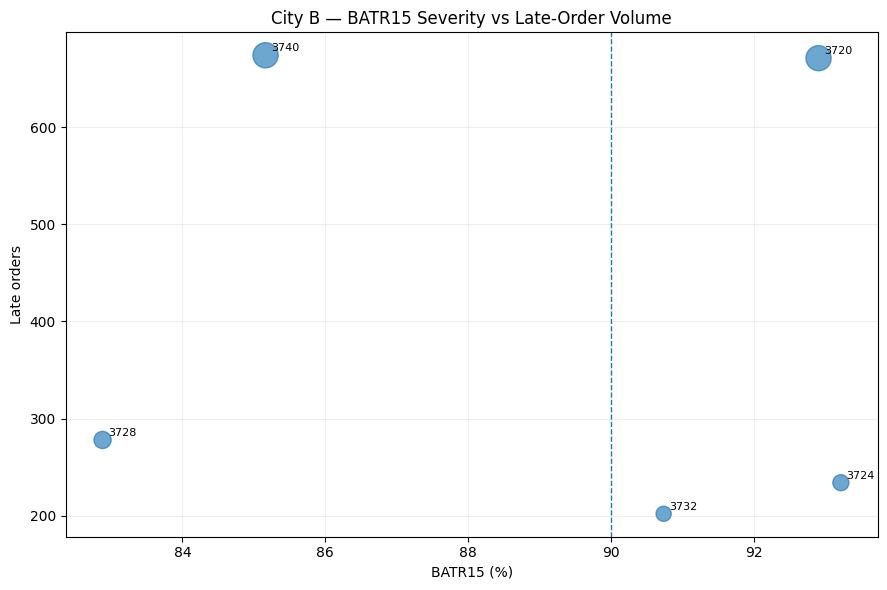

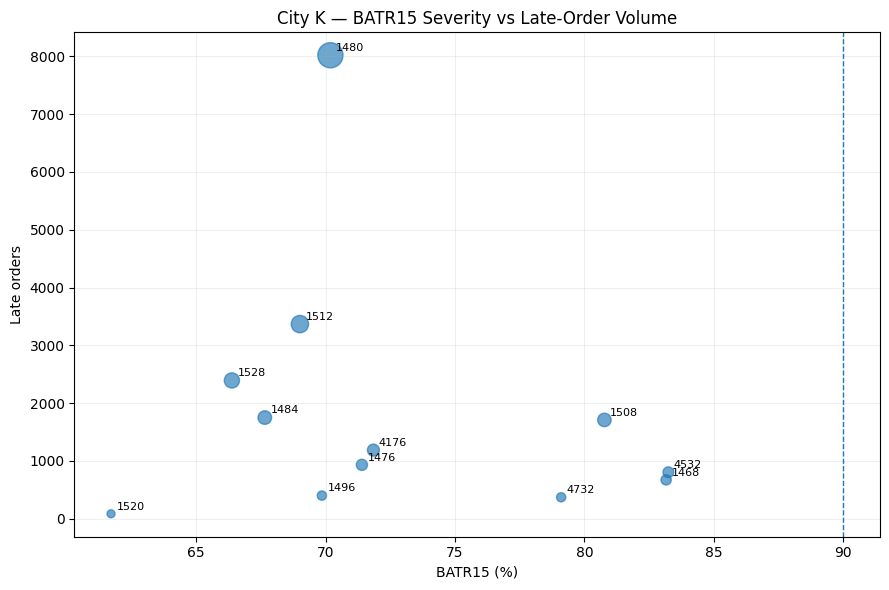

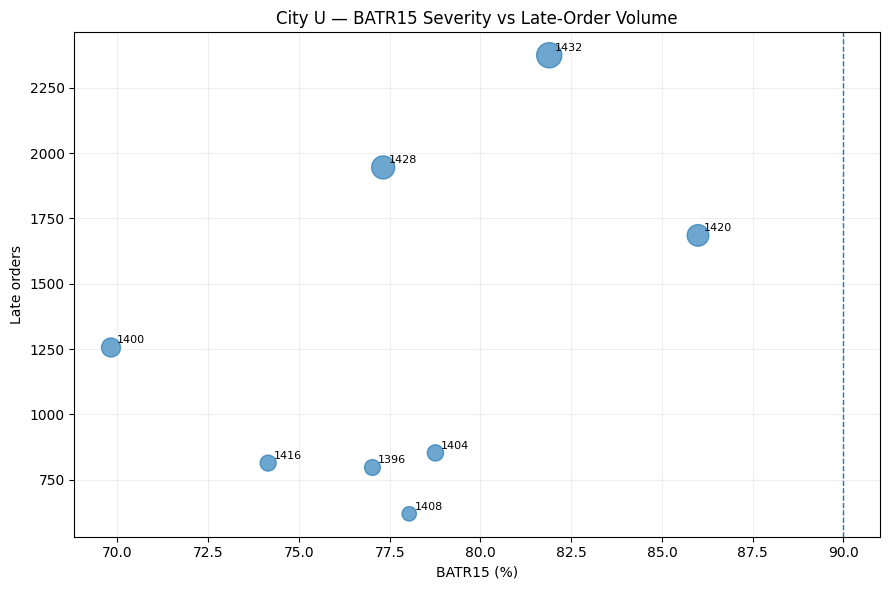

In [10]:
for city in sorted(district_batr["order_city"].unique()):

    p = district_batr[
        (district_batr["order_city"] == city)
        & (
            district_batr["Orders"]
            >= MIN_DISTRICT_ORDERS_FOR_RANKING
        )
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 6))

    sizes = (
        30
        + 300
        * p["Late_Orders"]
        / max(p["Late_Orders"].max(), 1)
    )

    ax.scatter(
        p["BATR15 (%)"],
        p["Late_Orders"],
        s=sizes,
        alpha=.65
    )

    for _, row in p.iterrows():
        ax.annotate(
            str(int(row["district"])),
            (
                row["BATR15 (%)"],
                row["Late_Orders"]
            ),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8
        )

    ax.axvline(
        90,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"City {city} — BATR15 Severity vs Late-Order Volume"
    )

    ax.set_xlabel("BATR15 (%)")
    ax.set_ylabel("Late orders")
    ax.grid(alpha=.2)

    plt.tight_layout()
    plt.show()


In [11]:
def trimmed_mean(series, lower=.01, upper=.99):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s[(s >= lo) & (s <= hi)].mean()

def summarize_components(grouped):
    return (
        grouped.agg(
            Orders=("order_id", "count"),
            BATR15_Rate=("BATR15", "mean"),

            Acceptance_Mean=("Acceptance_min", "mean"),
            Acceptance_TrimmedMean=("Acceptance_min", trimmed_mean),
            Acceptance_Median=("Acceptance_min", "median"),
            Acceptance_P75=("Acceptance_min", lambda s: s.quantile(.75)),
            Acceptance_P90=("Acceptance_min", lambda s: s.quantile(.90)),
            Acceptance_P95=("Acceptance_min", lambda s: s.quantile(.95)),

            Arrival_Mean=("Arrival_min", "mean"),
            Arrival_TrimmedMean=("Arrival_min", trimmed_mean),
            Arrival_Median=("Arrival_min", "median"),
            Arrival_P75=("Arrival_min", lambda s: s.quantile(.75)),
            Arrival_P90=("Arrival_min", lambda s: s.quantile(.90)),
            Arrival_P95=("Arrival_min", lambda s: s.quantile(.95)),

            BATR_Mean=("BATR_min", "mean"),
            BATR_Median=("BATR_min", "median"),
            BATR_P90=("BATR_min", lambda s: s.quantile(.90)),
            BATR_P95=("BATR_min", lambda s: s.quantile(.95))
        )
        .reset_index()
    )

city_components = summarize_components(
    seq.groupby("order_city")
)

city_components["BATR15 (%)"] = (
    city_components["BATR15_Rate"] * 100
)

display(city_components)


,order_city,Orders,BATR15_Rate,Acceptance_Mean,Acceptance_TrimmedMean,Acceptance_Median,Acceptance_P75,Acceptance_P90,Acceptance_P95,Arrival_Mean,Arrival_TrimmedMean,Arrival_Median,Arrival_P75,Arrival_P90,Arrival_P95,BATR_Mean,BATR_Median,BATR_P90,BATR_P95,BATR15 (%)
0,B,14776,0.860,2.662,2.131,0.000,1.000,10.000,15.000,5.418,4.653,4.000,6.000,11.000,15.000,8.080,5.000,18.000,25.000,86.025
1,K,69389,0.687,5.945,5.457,2.000,11.000,15.000,20.000,7.802,6.173,5.000,8.000,13.000,20.000,13.747,10.000,26.000,34.000,68.651
2,U,43609,0.762,5.139,4.560,1.000,8.000,14.000,19.000,6.249,5.260,4.000,7.000,11.000,15.000,11.388,8.000,23.000,30.000,76.246


In [12]:
district_components = summarize_components(
    seq.groupby(["order_city", "district"])
)

district_components["BATR15 (%)"] = (
    district_components["BATR15_Rate"] * 100
)

display(
    district_components.sort_values(
        ["order_city", "BATR15 (%)"]
    )
)


,order_city,district,Orders,BATR15_Rate,Acceptance_Mean,Acceptance_TrimmedMean,Acceptance_Median,Acceptance_P75,Acceptance_P90,Acceptance_P95,Arrival_Mean,Arrival_TrimmedMean,Arrival_Median,Arrival_P75,Arrival_P90,Arrival_P95,BATR_Mean,BATR_Median,BATR_P90,BATR_P95,BATR15 (%)
2,B,3728,1367,0.797,4.228,3.636,0.000,5.000,13.000,21.000,6.446,5.232,4.000,7.000,11.000,15.000,10.673,6.000,22.000,30.000,79.663
4,B,3740,3352,0.799,2.926,2.099,0.000,0.000,9.000,16.000,8.561,6.745,5.000,10.000,16.000,21.000,11.487,6.000,23.000,30.000,79.893
5,B,3752,47,0.851,3.298,2.696,0.000,1.500,11.800,20.100,3.872,3.652,3.000,5.500,6.400,10.100,7.170,4.000,18.400,26.700,85.106
3,B,3732,1590,0.873,2.904,2.398,0.000,2.000,11.000,15.550,4.326,4.119,3.000,6.000,9.000,12.000,7.230,4.000,18.000,24.000,87.296
0,B,3720,6154,0.891,2.331,1.896,0.000,1.000,9.000,13.000,4.263,3.880,3.000,6.000,9.000,12.000,6.594,4.000,16.000,22.000,89.113
1,B,3724,2266,0.897,2.045,1.717,0.000,1.000,8.000,13.000,4.082,3.820,3.000,5.000,9.000,12.000,6.127,4.000,16.000,21.000,89.673
7,K,1472,25,0.400,8.840,7.917,10.000,12.000,15.800,21.000,10.600,8.792,7.000,10.000,23.000,28.200,19.440,17.000,38.800,42.800,40.000
11,K,1488,78,0.449,9.603,9.221,11.000,13.000,18.000,26.000,9.846,9.117,6.500,10.000,23.900,31.300,19.449,16.000,38.200,48.450,44.872
16,K,1520,215,0.605,6.079,5.670,4.000,11.000,13.000,17.000,7.456,7.019,6.000,9.000,14.000,20.300,13.535,11.000,25.600,37.500,60.465
17,K,1528,6574,0.636,7.541,7.058,6.000,12.000,17.000,22.000,6.632,5.842,5.000,7.000,12.000,17.000,14.173,12.000,27.000,35.000,63.614


In [13]:
city_base = city_components.set_index("order_city")

benchmark = district_components.copy()

for metric in [
    "Acceptance_Mean",
    "Acceptance_TrimmedMean",
    "Acceptance_Median",
    "Acceptance_P90",
    "Acceptance_P95",
    "Arrival_Mean",
    "Arrival_TrimmedMean",
    "Arrival_Median",
    "Arrival_P90",
    "Arrival_P95",
    "BATR_Mean",
    "BATR_Median",
    "BATR_P90"
]:
    benchmark[f"City_{metric}"] = (
        benchmark["order_city"]
        .map(city_base[metric])
    )

    benchmark[f"{metric}_Gap_vs_City"] = (
        benchmark[metric]
        - benchmark[f"City_{metric}"]
    )

benchmark["Acceptance_P90_GapPct_vs_City"] = (
    benchmark["Acceptance_P90_Gap_vs_City"]
    / benchmark["City_Acceptance_P90"]
    * 100
)

benchmark["Arrival_P90_GapPct_vs_City"] = (
    benchmark["Arrival_P90_Gap_vs_City"]
    / benchmark["City_Arrival_P90"]
    * 100
)

benchmark["Primary_Tail_Deterioration"] = np.where(
    (
        benchmark["Acceptance_P90_Gap_vs_City"] <= 0
    )
    & (
        benchmark["Arrival_P90_Gap_vs_City"] <= 0
    ),
    "Neither component worse than city",
    np.where(
        benchmark["Acceptance_P90_GapPct_vs_City"]
        > benchmark["Arrival_P90_GapPct_vs_City"],
        "Acceptance tail",
        "Arrival tail"
    )
)

display(
    benchmark[
        [
            "order_city",
            "district",
            "Orders",
            "BATR15 (%)",

            "Acceptance_Median",
            "City_Acceptance_Median",
            "Acceptance_Median_Gap_vs_City",
            "Acceptance_P90",
            "City_Acceptance_P90",
            "Acceptance_P90_Gap_vs_City",
            "Acceptance_P90_GapPct_vs_City",

            "Arrival_Median",
            "City_Arrival_Median",
            "Arrival_Median_Gap_vs_City",
            "Arrival_P90",
            "City_Arrival_P90",
            "Arrival_P90_Gap_vs_City",
            "Arrival_P90_GapPct_vs_City",

            "Primary_Tail_Deterioration"
        ]
    ].sort_values(
        ["order_city", "BATR15 (%)"]
    )
)


,order_city,district,Orders,BATR15 (%),Acceptance_Median,City_Acceptance_Median,Acceptance_Median_Gap_vs_City,Acceptance_P90,City_Acceptance_P90,Acceptance_P90_Gap_vs_City,Acceptance_P90_GapPct_vs_City,Arrival_Median,City_Arrival_Median,Arrival_Median_Gap_vs_City,Arrival_P90,City_Arrival_P90,Arrival_P90_Gap_vs_City,Arrival_P90_GapPct_vs_City,Primary_Tail_Deterioration
2,B,3728,1367,79.663,0.000,0.000,0.000,13.000,10.000,3.000,30.000,4.000,4.000,0.000,11.000,11.000,0.000,0.000,Acceptance tail
4,B,3740,3352,79.893,0.000,0.000,0.000,9.000,10.000,-1.000,-10.000,5.000,4.000,1.000,16.000,11.000,5.000,45.455,Arrival tail
5,B,3752,47,85.106,0.000,0.000,0.000,11.800,10.000,1.800,18.000,3.000,4.000,-1.000,6.400,11.000,-4.600,-41.818,Acceptance tail
3,B,3732,1590,87.296,0.000,0.000,0.000,11.000,10.000,1.000,10.000,3.000,4.000,-1.000,9.000,11.000,-2.000,-18.182,Acceptance tail
0,B,3720,6154,89.113,0.000,0.000,0.000,9.000,10.000,-1.000,-10.000,3.000,4.000,-1.000,9.000,11.000,-2.000,-18.182,Neither component worse than city
1,B,3724,2266,89.673,0.000,0.000,0.000,8.000,10.000,-2.000,-20.000,3.000,4.000,-1.000,9.000,11.000,-2.000,-18.182,Neither component worse than city
7,K,1472,25,40.000,10.000,2.000,8.000,15.800,15.000,0.800,5.333,7.000,5.000,2.000,23.000,13.000,10.000,76.923,Arrival tail
11,K,1488,78,44.872,11.000,2.000,9.000,18.000,15.000,3.000,20.000,6.500,5.000,1.500,23.900,13.000,10.900,83.846,Arrival tail
16,K,1520,215,60.465,4.000,2.000,2.000,13.000,15.000,-2.000,-13.333,6.000,5.000,1.000,14.000,13.000,1.000,7.692,Arrival tail
17,K,1528,6574,63.614,6.000,2.000,4.000,17.000,15.000,2.000,13.333,5.000,5.000,0.000,12.000,13.000,-1.000,-7.692,Acceptance tail


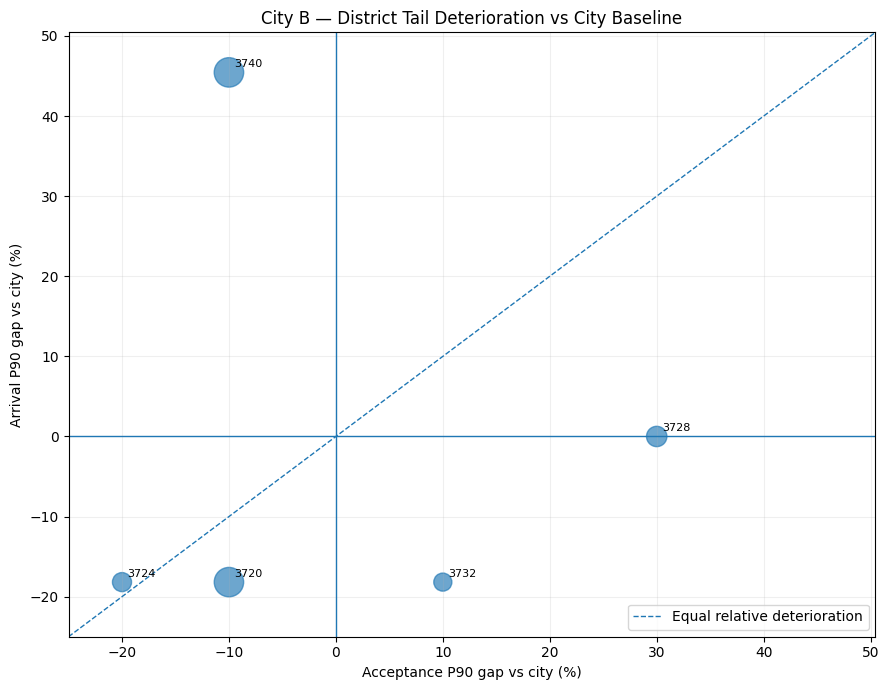

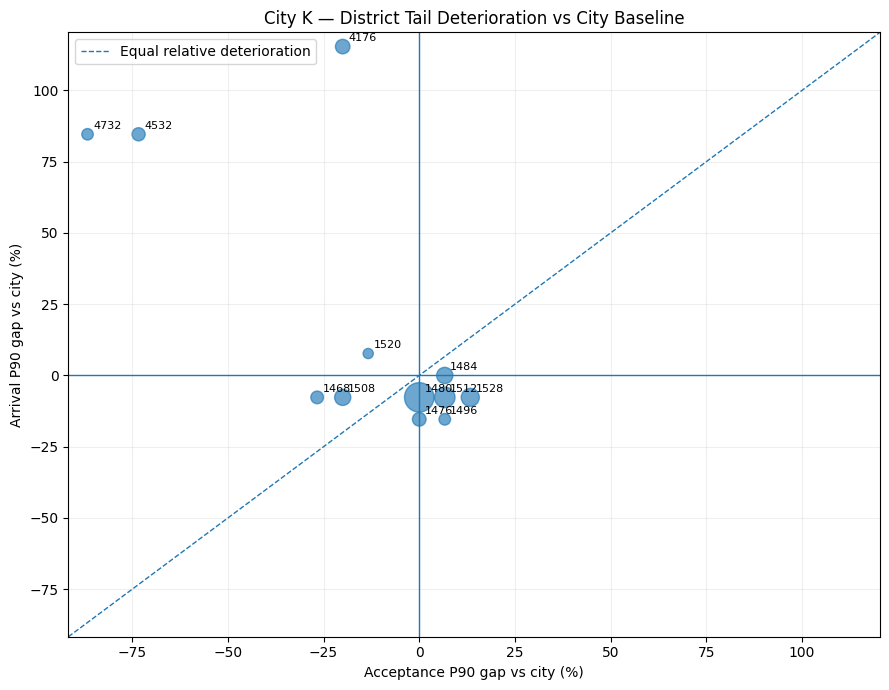

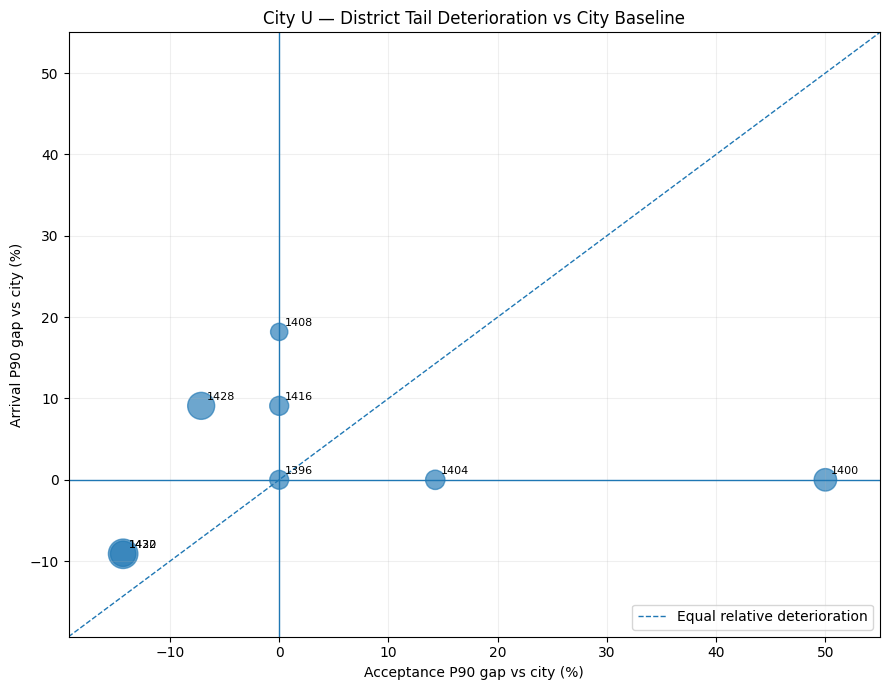

In [14]:
for city in sorted(benchmark["order_city"].unique()):

    p = benchmark[
        (benchmark["order_city"] == city)
        & (
            benchmark["Orders"]
            >= MIN_DISTRICT_ORDERS_FOR_RANKING
        )
    ].copy()

    late_lookup = (
        district_batr.set_index(
            ["order_city", "district"]
        )["Late_Orders"]
    )

    p["Late_Orders"] = [
        late_lookup.get((city, d), 0)
        for d in p["district"]
    ]

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = (
        50
        + 400
        * p["Late_Orders"]
        / max(p["Late_Orders"].max(), 1)
    )

    ax.scatter(
        p["Acceptance_P90_GapPct_vs_City"],
        p["Arrival_P90_GapPct_vs_City"],
        s=sizes,
        alpha=.65
    )

    for _, row in p.iterrows():
        ax.annotate(
            str(int(row["district"])),
            (
                row["Acceptance_P90_GapPct_vs_City"],
                row["Arrival_P90_GapPct_vs_City"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    ax.axvline(0, linewidth=1)
    ax.axhline(0, linewidth=1)

    lims = [
        min(
            p["Acceptance_P90_GapPct_vs_City"].min(),
            p["Arrival_P90_GapPct_vs_City"].min()
        ) - 5,
        max(
            p["Acceptance_P90_GapPct_vs_City"].max(),
            p["Arrival_P90_GapPct_vs_City"].max()
        ) + 5
    ]

    ax.plot(
        lims,
        lims,
        linestyle="--",
        linewidth=1,
        label="Equal relative deterioration"
    )

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_title(
        f"City {city} — District Tail Deterioration vs City Baseline"
    )

    ax.set_xlabel("Acceptance P90 gap vs city (%)")
    ax.set_ylabel("Arrival P90 gap vs city (%)")
    ax.legend()
    ax.grid(alpha=.2)

    plt.tight_layout()
    plt.show()


In [15]:
seq["hour"] = seq["start_time_slot"].dt.hour

city_hour_baseline = (
    seq.groupby(["order_city", "hour"])
    .agg(
        CityHour_Acceptance_Median=(
            "Acceptance_min", "median"
        ),
        CityHour_Acceptance_P90=(
            "Acceptance_min",
            lambda s: s.quantile(.90)
        ),
        CityHour_Arrival_Median=(
            "Arrival_min", "median"
        ),
        CityHour_Arrival_P90=(
            "Arrival_min",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

seq_adj = seq.merge(
    city_hour_baseline,
    on=["order_city", "hour"],
    how="left"
)

seq_adj["Acceptance_Dev_vs_CityHour"] = (
    seq_adj["Acceptance_min"]
    - seq_adj["CityHour_Acceptance_Median"]
)

seq_adj["Arrival_Dev_vs_CityHour"] = (
    seq_adj["Arrival_min"]
    - seq_adj["CityHour_Arrival_Median"]
)

display(city_hour_baseline)


,order_city,hour,CityHour_Acceptance_Median,CityHour_Acceptance_P90,CityHour_Arrival_Median,CityHour_Arrival_P90
0,B,0,0.000,19.000,4.000,11.000
1,B,1,3.000,3.000,13.000,13.000
2,B,7,0.000,11.200,6.000,11.200
3,B,8,0.000,11.000,4.000,10.700
4,B,9,0.000,9.700,3.000,11.000
5,B,10,0.000,2.000,4.000,10.300
6,B,11,0.000,5.000,4.000,13.000
7,B,12,0.000,12.000,4.000,11.000
8,B,13,0.000,13.000,4.000,10.000
9,B,14,0.000,11.000,3.000,10.000


In [16]:
district_adjusted = (
    seq_adj.groupby(["order_city", "district"])
    .agg(
        Orders=("order_id", "count"),

        Acceptance_Dev_Mean=(
            "Acceptance_Dev_vs_CityHour",
            "mean"
        ),
        Acceptance_Dev_Median=(
            "Acceptance_Dev_vs_CityHour",
            "median"
        ),
        Acceptance_Dev_P90=(
            "Acceptance_Dev_vs_CityHour",
            lambda s: s.quantile(.90)
        ),

        Arrival_Dev_Mean=(
            "Arrival_Dev_vs_CityHour",
            "mean"
        ),
        Arrival_Dev_Median=(
            "Arrival_Dev_vs_CityHour",
            "median"
        ),
        Arrival_Dev_P90=(
            "Arrival_Dev_vs_CityHour",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

display(
    district_adjusted.sort_values(
        ["order_city", "Acceptance_Dev_P90"],
        ascending=[True, False]
    )
)


,order_city,district,Orders,Acceptance_Dev_Mean,Acceptance_Dev_Median,Acceptance_Dev_P90,Arrival_Dev_Mean,Arrival_Dev_Median,Arrival_Dev_P90
2,B,3728,1367,4.228,0.000,13.000,2.710,1.000,8.000
5,B,3752,47,3.298,0.000,11.800,0.149,-1.000,3.400
3,B,3732,1590,2.904,0.000,11.000,0.730,0.000,5.000
0,B,3720,6154,2.331,0.000,9.000,0.564,-1.000,5.000
4,B,3740,3352,2.926,0.000,9.000,4.852,1.000,12.000
1,B,3724,2266,2.043,0.000,8.000,0.353,-1.000,5.000
11,K,1488,78,7.026,7.500,16.000,5.256,2.000,18.500
7,K,1472,25,7.240,6.000,14.400,6.000,2.000,18.000
10,K,1484,4971,4.361,2.000,14.000,1.854,0.000,8.000
15,K,1512,9753,4.429,2.000,14.000,1.716,0.000,7.000


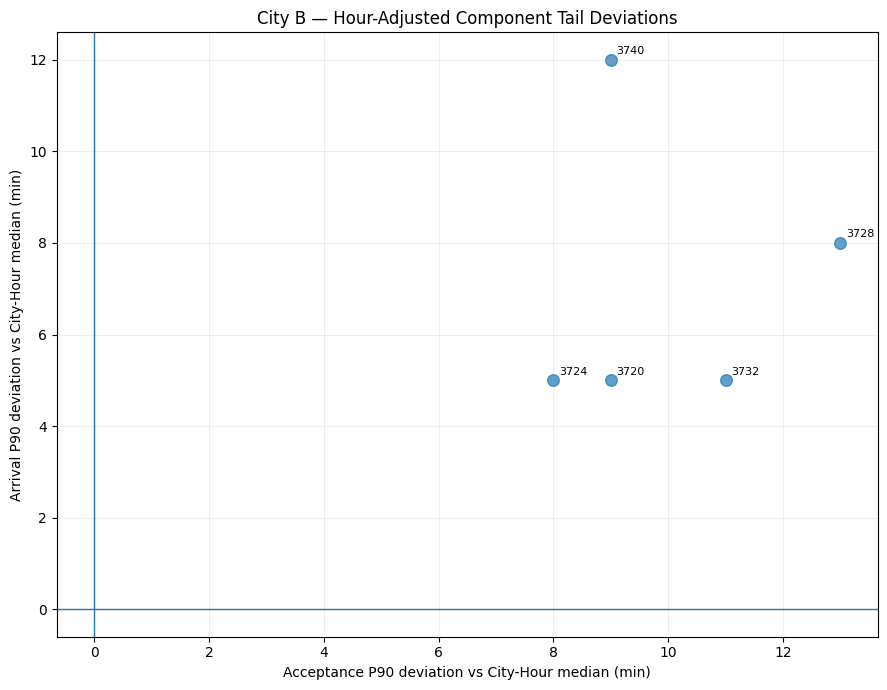

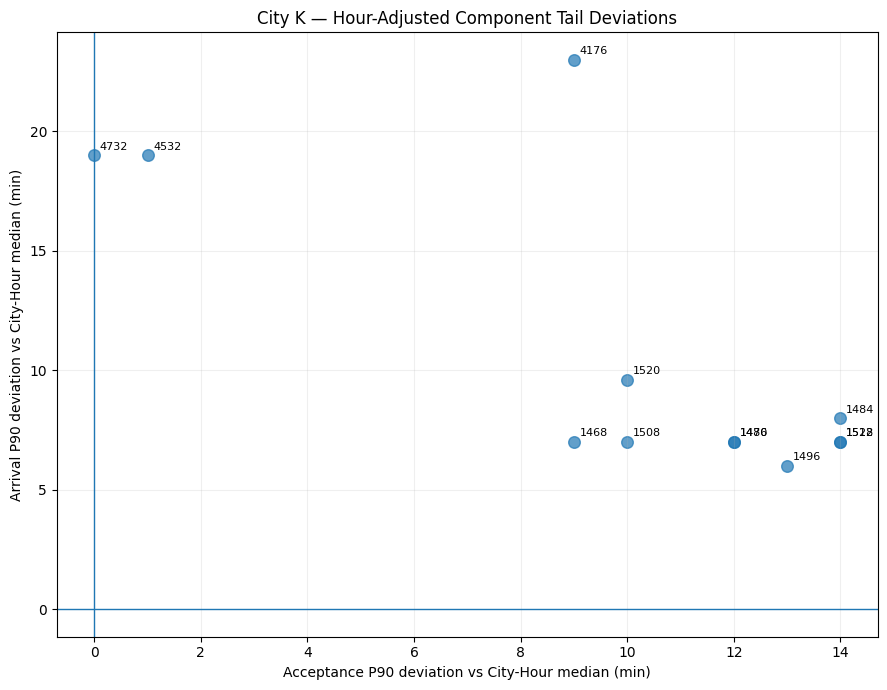

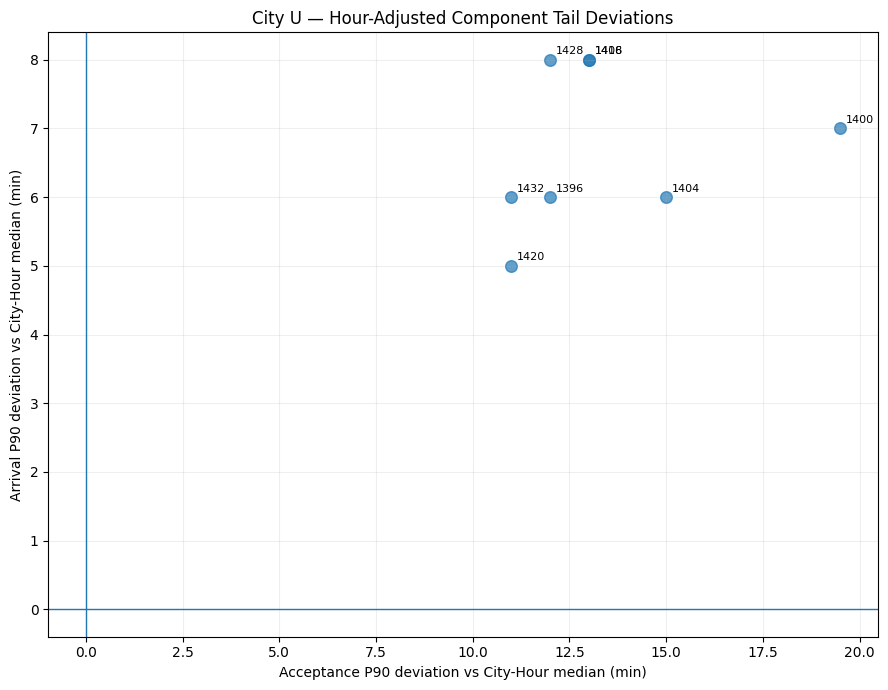

In [17]:
for city in sorted(district_adjusted["order_city"].unique()):

    p = district_adjusted[
        (district_adjusted["order_city"] == city)
        & (
            district_adjusted["Orders"]
            >= MIN_DISTRICT_ORDERS_FOR_RANKING
        )
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(
        p["Acceptance_Dev_P90"],
        p["Arrival_Dev_P90"],
        s=70,
        alpha=.7
    )

    for _, row in p.iterrows():
        ax.annotate(
            str(int(row["district"])),
            (
                row["Acceptance_Dev_P90"],
                row["Arrival_Dev_P90"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    ax.axvline(0, linewidth=1)
    ax.axhline(0, linewidth=1)

    ax.set_title(
        f"City {city} — Hour-Adjusted Component Tail Deviations"
    )

    ax.set_xlabel(
        "Acceptance P90 deviation vs City-Hour median (min)"
    )

    ax.set_ylabel(
        "Arrival P90 deviation vs City-Hour median (min)"
    )

    ax.grid(alpha=.2)

    plt.tight_layout()
    plt.show()


In [18]:
late_success = (
    seq.groupby(
        ["order_city", "district", "BATR15"]
    )
    .agg(
        Orders=("order_id", "count"),

        Acceptance_Median=(
            "Acceptance_min", "median"
        ),
        Acceptance_P90=(
            "Acceptance_min",
            lambda s: s.quantile(.90)
        ),

        Arrival_Median=(
            "Arrival_min", "median"
        ),
        Arrival_P90=(
            "Arrival_min",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

wide = late_success.pivot(
    index=["order_city", "district"],
    columns="BATR15"
)

wide.columns = [
    f"{metric}_BATR15_{status}"
    for metric, status in wide.columns
]

wide = wide.reset_index()

for metric in [
    "Acceptance_Median",
    "Acceptance_P90",
    "Arrival_Median",
    "Arrival_P90"
]:
    wide[f"{metric}_LateMinusSuccess"] = (
        wide[f"{metric}_BATR15_0"]
        - wide[f"{metric}_BATR15_1"]
    )

display(
    wide[
        [
            "order_city",
            "district",
            "Orders_BATR15_0",
            "Orders_BATR15_1",
            "Acceptance_Median_LateMinusSuccess",
            "Acceptance_P90_LateMinusSuccess",
            "Arrival_Median_LateMinusSuccess",
            "Arrival_P90_LateMinusSuccess"
        ]
    ].sort_values(
        [
            "order_city",
            "Orders_BATR15_0"
        ],
        ascending=[True, False]
    )
)


KeyError: 'Acceptance_Median_BATR15_0'

In [19]:
seq_adj["BATR15_Sequential"] = (
    (
        seq_adj["Acceptance_min"]
        + seq_adj["Arrival_min"]
    )
    <= 15
).astype(int)

seq_adj["BATR15_if_Acceptance_Normalized"] = (
    (
        seq_adj["CityHour_Acceptance_Median"]
        + seq_adj["Arrival_min"]
    )
    <= 15
).astype(int)

seq_adj["BATR15_if_Arrival_Normalized"] = (
    (
        seq_adj["Acceptance_min"]
        + seq_adj["CityHour_Arrival_Median"]
    )
    <= 15
).astype(int)

normalization = (
    seq_adj.groupby(["order_city", "district"])
    .agg(
        Orders=("order_id", "count"),

        Actual_BATR15=(
            "BATR15_Sequential",
            "mean"
        ),

        BATR15_if_Acceptance_Normalized=(
            "BATR15_if_Acceptance_Normalized",
            "mean"
        ),

        BATR15_if_Arrival_Normalized=(
            "BATR15_if_Arrival_Normalized",
            "mean"
        )
    )
    .reset_index()
)

normalization["Actual BATR15 (%)"] = (
    normalization["Actual_BATR15"] * 100
)

normalization[
    "Acceptance Normalization Impact (pp)"
] = (
    normalization[
        "BATR15_if_Acceptance_Normalized"
    ]
    - normalization["Actual_BATR15"]
) * 100

normalization[
    "Arrival Normalization Impact (pp)"
] = (
    normalization[
        "BATR15_if_Arrival_Normalized"
    ]
    - normalization["Actual_BATR15"]
) * 100

normalization[
    "Primary Normalization Opportunity"
] = np.where(
    normalization[
        "Acceptance Normalization Impact (pp)"
    ]
    >
    normalization[
        "Arrival Normalization Impact (pp)"
    ],
    "Acceptance",
    np.where(
        normalization[
            "Arrival Normalization Impact (pp)"
        ]
        >
        normalization[
            "Acceptance Normalization Impact (pp)"
        ],
        "Arrival",
        "Equal"
    )
)

display(
    normalization.sort_values(
        [
            "order_city",
            "Actual BATR15 (%)"
        ]
    )
)


,order_city,district,Orders,Actual_BATR15,BATR15_if_Acceptance_Normalized,BATR15_if_Arrival_Normalized,Actual BATR15 (%),Acceptance Normalization Impact (pp),Arrival Normalization Impact (pp),Primary Normalization Opportunity
2,B,3728,1367,0.797,0.952,0.881,79.663,15.582,8.413,Acceptance
4,B,3740,3352,0.799,0.888,0.925,79.893,8.860,12.649,Arrival
5,B,3752,47,0.851,1.000,0.894,85.106,14.894,4.255,Acceptance
3,B,3732,1590,0.873,0.975,0.918,87.296,10.252,4.528,Acceptance
0,B,3720,6154,0.891,0.972,0.933,89.113,8.109,4.160,Acceptance
1,B,3724,2266,0.897,0.973,0.940,89.673,7.635,4.325,Acceptance
7,K,1472,25,0.400,0.760,0.640,40.000,36.000,24.000,Acceptance
11,K,1488,78,0.449,0.821,0.577,44.872,37.179,12.821,Acceptance
16,K,1520,215,0.605,0.856,0.726,60.465,25.116,12.093,Acceptance
17,K,1528,6574,0.636,0.911,0.676,63.614,27.441,3.940,Acceptance


In [20]:
seq_adj["Acceptance_Positive_Excess"] = (
    seq_adj["Acceptance_Dev_vs_CityHour"]
    .clip(lower=0)
)

seq_adj["Arrival_Positive_Excess"] = (
    seq_adj["Arrival_Dev_vs_CityHour"]
    .clip(lower=0)
)

late_seq = seq_adj[
    seq_adj["BATR15_Sequential"] == 0
].copy()

excess = (
    late_seq.groupby(["order_city", "district"])
    .agg(
        Late_Orders=("order_id", "count"),

        Acceptance_Excess_Mean=(
            "Acceptance_Positive_Excess",
            "mean"
        ),
        Acceptance_Excess_Total=(
            "Acceptance_Positive_Excess",
            "sum"
        ),

        Arrival_Excess_Mean=(
            "Arrival_Positive_Excess",
            "mean"
        ),
        Arrival_Excess_Total=(
            "Arrival_Positive_Excess",
            "sum"
        )
    )
    .reset_index()
)

denom = (
    excess["Acceptance_Excess_Total"]
    + excess["Arrival_Excess_Total"]
)

excess["Acceptance Share of Excess (%)"] = np.where(
    denom > 0,
    excess["Acceptance_Excess_Total"]
    / denom
    * 100,
    np.nan
)

excess["Arrival Share of Excess (%)"] = np.where(
    denom > 0,
    excess["Arrival_Excess_Total"]
    / denom
    * 100,
    np.nan
)

display(
    excess.sort_values(
        [
            "order_city",
            "Late_Orders"
        ],
        ascending=[True, False]
    )
)


,order_city,district,Late_Orders,Acceptance_Excess_Mean,Acceptance_Excess_Total,Arrival_Excess_Mean,Arrival_Excess_Total,Acceptance Share of Excess (%),Arrival Share of Excess (%)
4,B,3740,674,12.006,"8,092.000",19.969,"13,459.000",37.548,62.452
0,B,3720,670,14.137,"9,472.000",8.251,"5,528.000",63.147,36.853
2,B,3728,278,16.029,"4,456.000",11.594,"3,223.000",58.028,41.972
1,B,3724,234,12.923,"3,024.000",7.132,"1,669.000",64.436,35.564
3,B,3732,202,16.272,"3,287.000",5.644,"1,140.000",74.249,25.751
5,B,3752,7,17.429,122.000,3.143,22.000,84.722,15.278
9,K,1480,8018,11.268,"90,347.000",10.366,"83,111.500",52.086,47.914
15,K,1512,3367,11.956,"40,255.000",6.281,"21,149.500",65.557,34.443
17,K,1528,2392,12.431,"29,735.000",6.603,"15,794.000",65.310,34.690
10,K,1484,1750,12.407,"21,713.000",6.553,"11,467.500",65.439,34.561


In [21]:
seq["month"] = (
    seq["start_time_slot"]
    .dt.to_period("M")
    .astype(str)
)

monthly = (
    seq.groupby(["order_city", "month"])
    .agg(
        Orders=("order_id", "count"),
        BATR15=("BATR15", "mean"),

        Acceptance_Mean=(
            "Acceptance_min", "mean"
        ),
        Acceptance_Median=(
            "Acceptance_min", "median"
        ),
        Acceptance_P90=(
            "Acceptance_min",
            lambda s: s.quantile(.90)
        ),

        Arrival_Mean=(
            "Arrival_min", "mean"
        ),
        Arrival_Median=(
            "Arrival_min", "median"
        ),
        Arrival_P90=(
            "Arrival_min",
            lambda s: s.quantile(.90)
        ),

        BATR_Mean=("BATR_min", "mean"),
        BATR_P90=(
            "BATR_min",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

monthly["BATR15 (%)"] = (
    monthly["BATR15"] * 100
)

display(monthly)


,order_city,month,Orders,BATR15,Acceptance_Mean,Acceptance_Median,Acceptance_P90,Arrival_Mean,Arrival_Median,Arrival_P90,BATR_Mean,BATR_P90,BATR15 (%)
0,B,2025-08,4096,0.838,3.220,0.000,11.000,6.604,4.000,11.000,9.823,21.000,83.838
1,B,2025-09,4596,0.857,2.459,0.000,10.000,5.069,4.000,11.000,7.528,19.000,85.727
2,B,2025-10,6084,0.877,2.440,0.000,8.000,4.883,3.000,10.700,7.323,17.000,87.722
3,K,2025-08,19216,0.677,6.454,3.000,16.000,9.184,5.000,13.000,15.639,26.000,67.735
4,K,2025-09,22626,0.694,5.985,2.000,14.000,7.083,5.000,13.000,13.068,26.000,69.376
5,K,2025-10,27547,0.687,5.557,2.000,14.000,7.428,5.000,15.000,12.985,27.000,68.694
6,U,2025-08,12362,0.729,6.150,2.000,16.000,6.096,4.000,11.000,12.246,26.000,72.917
7,U,2025-09,13896,0.791,4.625,0.000,13.000,5.459,4.000,11.000,10.084,21.000,79.052
8,U,2025-10,17351,0.764,4.830,1.000,13.000,6.991,4.000,11.000,11.821,22.000,76.370


In [22]:
monthly_change = monthly.sort_values(
    ["order_city", "month"]
).copy()

for col in [
    "BATR_Mean",
    "Acceptance_Mean",
    "Arrival_Mean",
    "BATR15"
]:
    monthly_change[f"Delta_{col}"] = (
        monthly_change.groupby("order_city")[col]
        .diff()
    )

monthly_change["Identity_Check"] = (
    monthly_change["Delta_BATR_Mean"]
    - (
        monthly_change["Delta_Acceptance_Mean"]
        + monthly_change["Delta_Arrival_Mean"]
    )
)

display(
    monthly_change[
        [
            "order_city",
            "month",
            "BATR15 (%)",
            "BATR_Mean",
            "Acceptance_Mean",
            "Arrival_Mean",
            "Delta_BATR_Mean",
            "Delta_Acceptance_Mean",
            "Delta_Arrival_Mean",
            "Identity_Check"
        ]
    ]
)


,order_city,month,BATR15 (%),BATR_Mean,Acceptance_Mean,Arrival_Mean,Delta_BATR_Mean,Delta_Acceptance_Mean,Delta_Arrival_Mean,Identity_Check
0,B,2025-08,83.838,9.823,3.220,6.604,NaN,NaN,NaN,NaN
1,B,2025-09,85.727,7.528,2.459,5.069,-2.295,-0.761,-1.535,0.000
2,B,2025-10,87.722,7.323,2.440,4.883,-0.205,-0.020,-0.185,0.000
3,K,2025-08,67.735,15.639,6.454,9.184,NaN,NaN,NaN,NaN
4,K,2025-09,69.376,13.068,5.985,7.083,-2.571,-0.470,-2.101,0.000
5,K,2025-10,68.694,12.985,5.557,7.428,-0.083,-0.428,0.345,0.000
6,U,2025-08,72.917,12.246,6.150,6.096,NaN,NaN,NaN,NaN
7,U,2025-09,79.052,10.084,4.625,5.459,-2.162,-1.525,-0.637,-0.000
8,U,2025-10,76.370,11.821,4.830,6.991,1.736,0.205,1.531,0.000


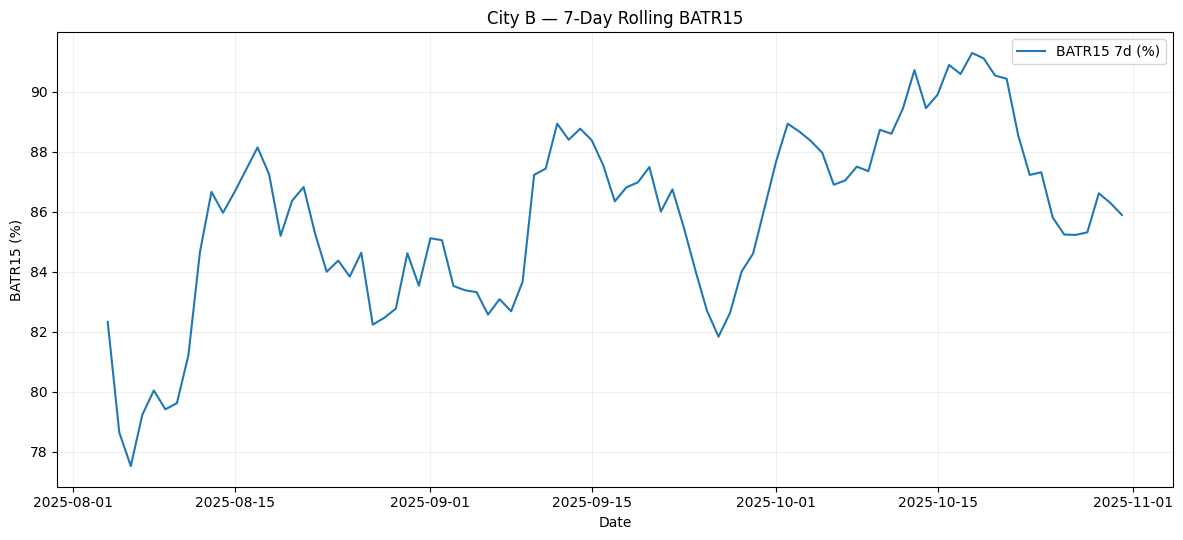

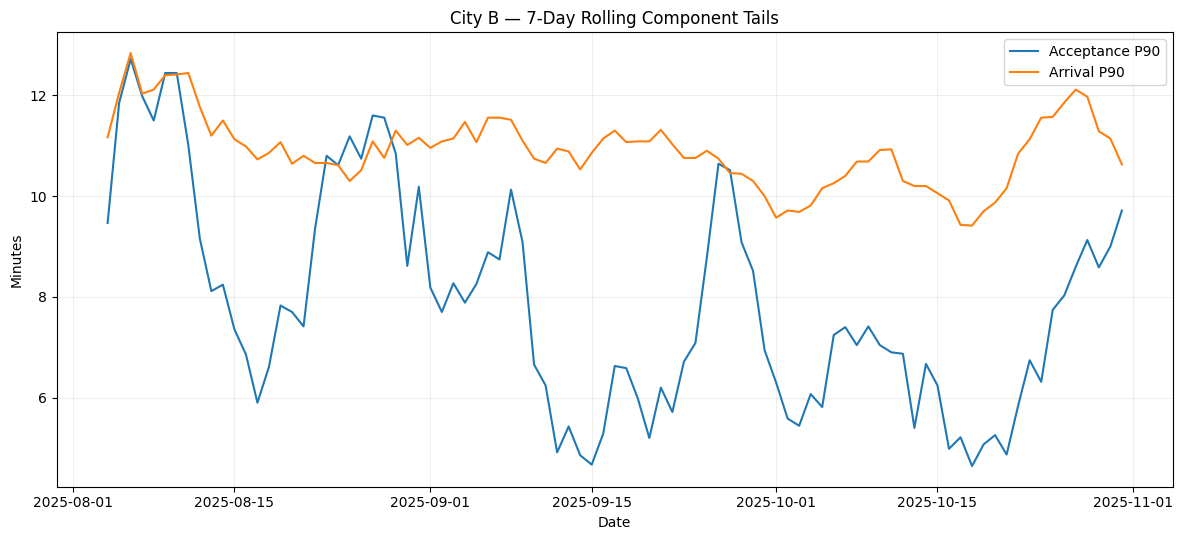

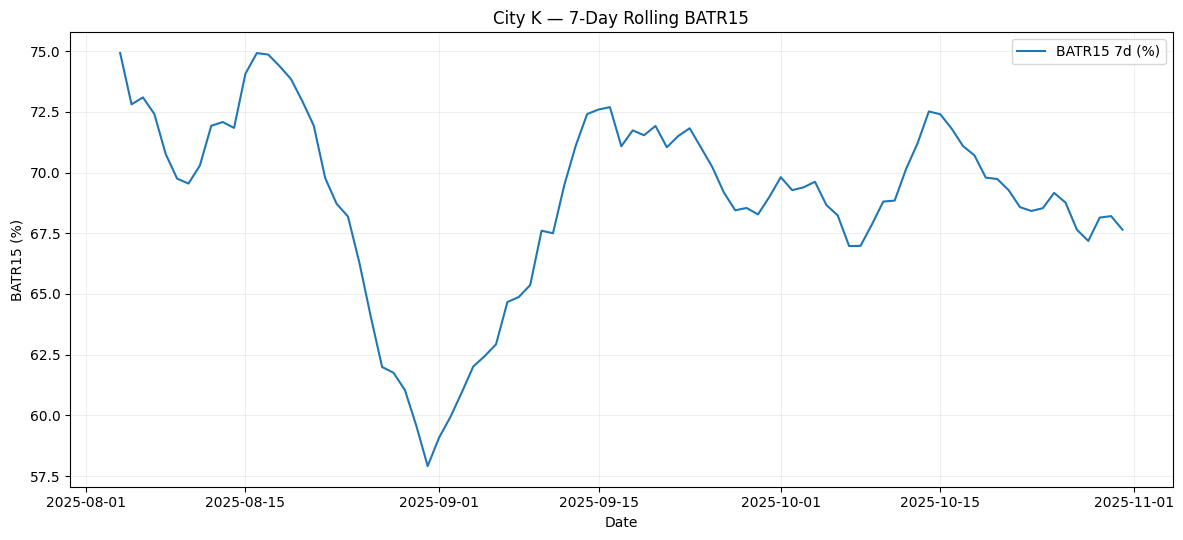

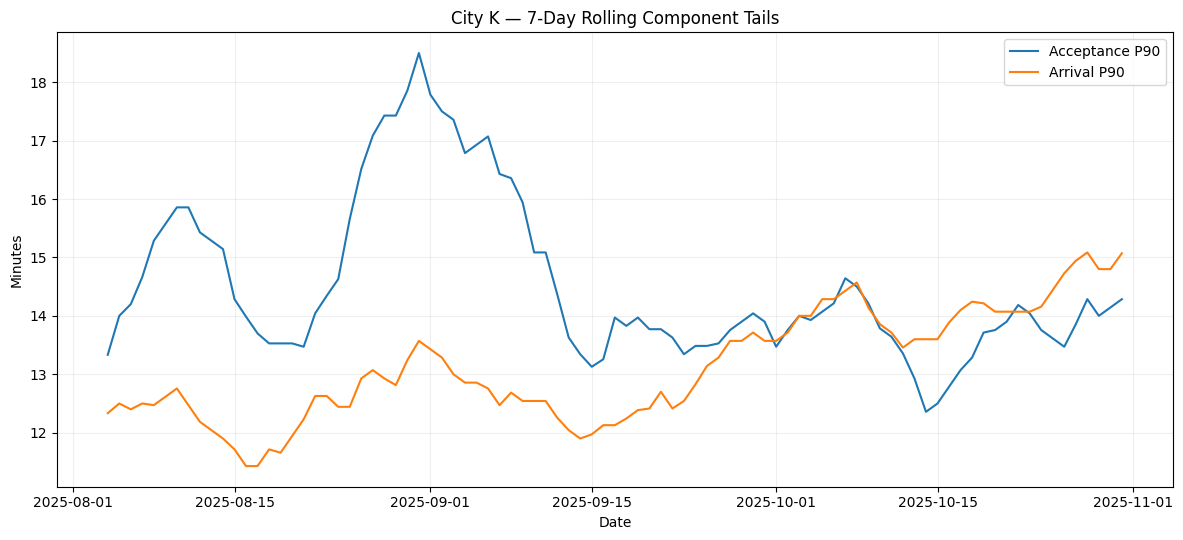

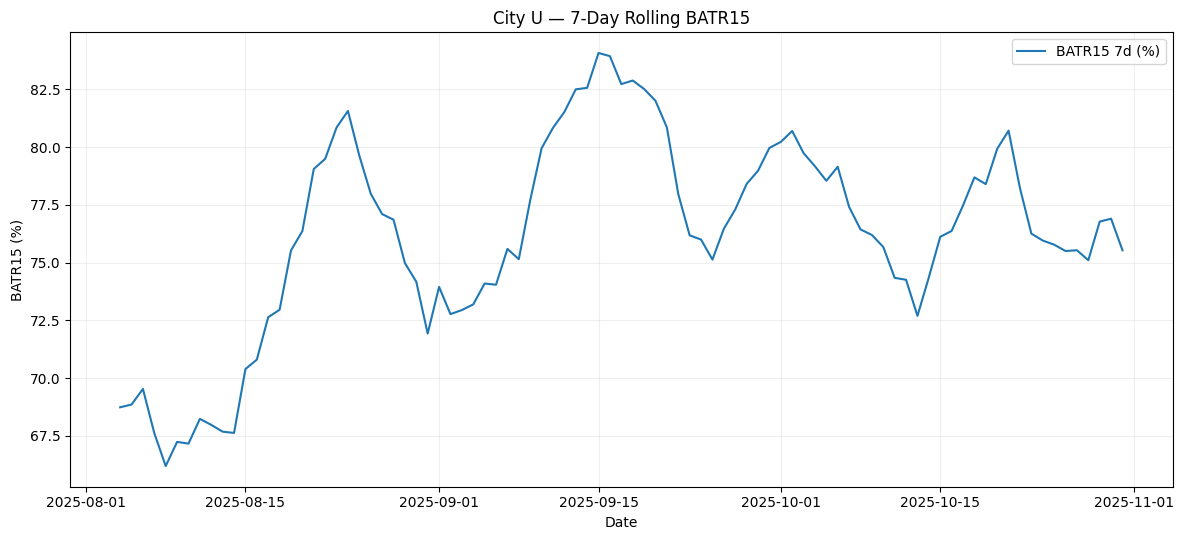

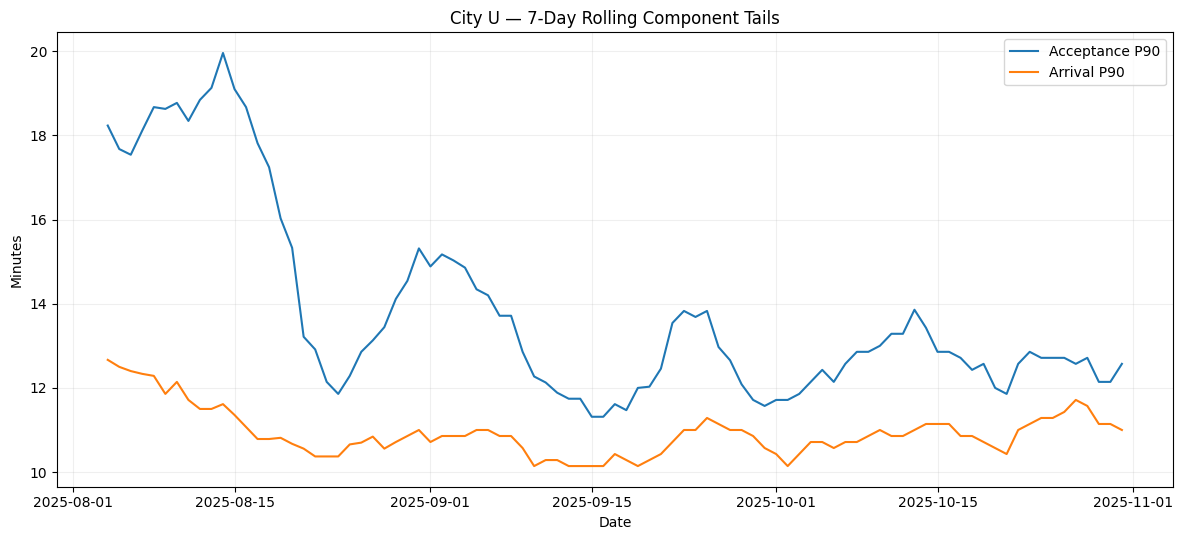

In [23]:
daily = (
    seq.assign(
        date=seq["start_time_slot"].dt.floor("D")
    )
    .groupby(["order_city", "date"])
    .agg(
        Orders=("order_id", "count"),
        BATR15_Successes=("BATR15", "sum"),
        Acceptance_P90=(
            "Acceptance_min",
            lambda s: s.quantile(.90)
        ),
        Arrival_P90=(
            "Arrival_min",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

for city in sorted(daily["order_city"].unique()):

    p = daily[
        daily["order_city"] == city
    ].sort_values("date").copy()

    p["BATR15_7d"] = (
        p["BATR15_Successes"]
        .rolling(7, min_periods=3)
        .sum()
        /
        p["Orders"]
        .rolling(7, min_periods=3)
        .sum()
        * 100
    )

    p["Acceptance_P90_7d"] = (
        p["Acceptance_P90"]
        .rolling(7, min_periods=3)
        .mean()
    )

    p["Arrival_P90_7d"] = (
        p["Arrival_P90"]
        .rolling(7, min_periods=3)
        .mean()
    )

    fig, ax = plt.subplots(figsize=(12, 5.5))

    ax.plot(
        p["date"],
        p["BATR15_7d"],
        label="BATR15 7d (%)"
    )

    ax.set_title(
        f"City {city} — 7-Day Rolling BATR15"
    )

    ax.set_ylabel("BATR15 (%)")
    ax.set_xlabel("Date")
    ax.grid(alpha=.2)
    ax.legend()

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5.5))

    ax.plot(
        p["date"],
        p["Acceptance_P90_7d"],
        label="Acceptance P90"
    )

    ax.plot(
        p["date"],
        p["Arrival_P90_7d"],
        label="Arrival P90"
    )

    ax.set_title(
        f"City {city} — 7-Day Rolling Component Tails"
    )

    ax.set_ylabel("Minutes")
    ax.set_xlabel("Date")
    ax.grid(alpha=.2)
    ax.legend()

    plt.tight_layout()
    plt.show()


In [24]:
panel_source = seq.copy()

panel_source["time_bin_15m"] = (
    panel_source["start_time_slot"]
    .dt.floor("15min")
)

district_15m = (
    panel_source.groupby(
        [
            "order_city",
            "district",
            "time_bin_15m"
        ]
    )
    .agg(
        Orders=("order_id", "count"),
        Unique_Bikers=("biker", "nunique"),

        BATR15=("BATR15", "mean"),

        Acceptance_Mean=(
            "Acceptance_min", "mean"
        ),
        Acceptance_P90=(
            "Acceptance_min",
            lambda s: s.quantile(.90)
        ),

        Arrival_Mean=(
            "Arrival_min", "mean"
        ),
        Arrival_P90=(
            "Arrival_min",
            lambda s: s.quantile(.90)
        )
    )
    .reset_index()
)

district_15m["Orders_per_Observed_Biker"] = (
    district_15m["Orders"]
    / district_15m["Unique_Bikers"].replace(0, np.nan)
)

display(district_15m.head())


,order_city,district,time_bin_15m,Orders,Unique_Bikers,BATR15,Acceptance_Mean,Acceptance_P90,Arrival_Mean,Arrival_P90,Orders_per_Observed_Biker
0,B,3720,2025-08-02 07:45:00,1,1,0.000,27.000,27.000,4.000,4.000,1.000
1,B,3720,2025-08-02 08:15:00,1,1,1.000,4.000,4.000,4.000,4.000,1.000
2,B,3720,2025-08-02 09:30:00,1,1,1.000,1.000,1.000,2.000,2.000,1.000
3,B,3720,2025-08-02 10:00:00,2,2,1.000,0.000,0.000,2.500,3.700,1.000
4,B,3720,2025-08-02 10:15:00,1,1,1.000,0.000,0.000,7.000,7.000,1.000


In [25]:
def safe_spearman(x, y):
    mask = pd.Series(x).notna() & pd.Series(y).notna()
    if mask.sum() < 5:
        return np.nan
    return spearmanr(
        pd.Series(x)[mask],
        pd.Series(y)[mask]
    ).statistic

load_associations = []

for city in sorted(district_15m["order_city"].unique()):

    p = district_15m[
        district_15m["order_city"] == city
    ]

    for load_metric in [
        "Orders",
        "Orders_per_Observed_Biker"
    ]:
        load_associations.append({
            "City": city,
            "Load Metric": load_metric,
            "Spearman with Acceptance Mean": safe_spearman(
                p[load_metric],
                p["Acceptance_Mean"]
            ),
            "Spearman with Arrival Mean": safe_spearman(
                p[load_metric],
                p["Arrival_Mean"]
            ),
            "Spearman with Acceptance P90": safe_spearman(
                p[load_metric],
                p["Acceptance_P90"]
            ),
            "Spearman with Arrival P90": safe_spearman(
                p[load_metric],
                p["Arrival_P90"]
            )
        })

load_association_table = pd.DataFrame(
    load_associations
)

display(load_association_table)


,City,Load Metric,Spearman with Acceptance Mean,Spearman with Arrival Mean,Spearman with Acceptance P90,Spearman with Arrival P90
0,B,Orders,0.251,0.105,0.290,0.274
1,B,Orders_per_Observed_Biker,0.138,0.017,0.153,0.061
2,K,Orders,0.309,0.131,0.453,0.373
3,K,Orders_per_Observed_Biker,0.085,0.017,0.126,0.071
4,U,Orders,0.171,0.099,0.317,0.341
5,U,Orders_per_Observed_Biker,0.050,0.020,0.095,0.080


In [26]:
biker_district_count = (
    df.dropna(subset=["biker", "district"])
      .groupby("biker")["district"]
      .nunique()
)

biker_district_pairs = (
    df.dropna(subset=["biker", "district"])
      [["order_city", "district", "biker"]]
      .drop_duplicates()
)

biker_district_pairs["Biker_District_Count"] = (
    biker_district_pairs["biker"]
    .map(biker_district_count)
)

biker_district_pairs["Exclusive_to_One_District"] = (
    biker_district_pairs["Biker_District_Count"] == 1
).astype(int)

district_biker_structure = (
    biker_district_pairs.groupby(
        ["order_city", "district"]
    )
    .agg(
        Unique_Bikers=("biker", "nunique"),
        Exclusive_Biker_Share=(
            "Exclusive_to_One_District",
            "mean"
        )
    )
    .reset_index()
)

district_order_per_biker = (
    df.dropna(subset=["biker", "district"])
    .groupby(["order_city", "district"])
    .agg(
        Orders=("order_id", "count"),
        Unique_Bikers_Orders=("biker", "nunique")
    )
    .reset_index()
)

district_order_per_biker[
    "Orders_per_Unique_Biker"
] = (
    district_order_per_biker["Orders"]
    / district_order_per_biker["Unique_Bikers_Orders"]
)

district_biker_structure = (
    district_biker_structure.merge(
        district_order_per_biker[
            [
                "order_city",
                "district",
                "Orders_per_Unique_Biker"
            ]
        ],
        on=["order_city", "district"],
        how="left"
    )
)

district_biker_structure[
    "Exclusive Biker Share (%)"
] = (
    district_biker_structure["Exclusive_Biker_Share"]
    * 100
)

display(
    district_biker_structure.sort_values(
        "Exclusive Biker Share (%)",
        ascending=False
    )
)


,order_city,district,Unique_Bikers,Exclusive_Biker_Share,Orders_per_Unique_Biker,Exclusive Biker Share (%)
19,K,4532,87,0.977,55.138,97.701
18,K,4176,97,0.959,43.464,95.876
20,K,4732,33,0.939,53.788,93.939
4,B,3740,158,0.456,28.753,45.570
23,U,1400,554,0.141,7.513,14.079
9,K,1480,1659,0.116,16.210,11.634
28,U,1420,715,0.103,16.827,10.350
7,K,1472,23,0.087,1.087,8.696
22,U,1396,443,0.084,7.831,8.352
12,K,1492,24,0.083,1.250,8.333


In [27]:
screening_rows = []

for city in sorted(seq["order_city"].unique()):

    p = seq[seq["order_city"] == city]

    for feature in [
        "order_fare",
        "total_distance"
    ]:
        screening_rows.append({
            "City": city,
            "Feature": feature,

            "Spearman with Acceptance": safe_spearman(
                p[feature],
                p["Acceptance_min"]
            ),

            "Spearman with Arrival": safe_spearman(
                p[feature],
                p["Arrival_min"]
            ),

            "Spearman with BATR": safe_spearman(
                p[feature],
                p["BATR_min"]
            )
        })

fare_distance_screening = pd.DataFrame(
    screening_rows
)

display(fare_distance_screening)


,City,Feature,Spearman with Acceptance,Spearman with Arrival,Spearman with BATR
0,B,order_fare,0.190,0.144,0.208
1,B,total_distance,0.031,0.050,0.048
2,K,order_fare,0.210,0.193,0.285
3,K,total_distance,0.022,0.096,0.070
4,U,order_fare,0.364,0.201,0.353
5,U,total_distance,0.069,0.103,0.100


In [28]:
rca = district_batr[
    [
        "order_city",
        "district",
        "Orders",
        "Late_Orders",
        "BATR15 (%)",
        "BATR_P90",
        "Share of All Late Orders (%)"
    ]
].copy()

rca = rca.merge(
    benchmark[
        [
            "order_city",
            "district",

            "Acceptance_Median_Gap_vs_City",
            "Acceptance_P90_Gap_vs_City",
            "Acceptance_P90_GapPct_vs_City",

            "Arrival_Median_Gap_vs_City",
            "Arrival_P90_Gap_vs_City",
            "Arrival_P90_GapPct_vs_City",

            "Primary_Tail_Deterioration"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

rca = rca.merge(
    district_adjusted[
        [
            "order_city",
            "district",
            "Acceptance_Dev_Median",
            "Acceptance_Dev_P90",
            "Arrival_Dev_Median",
            "Arrival_Dev_P90"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

rca = rca.merge(
    normalization[
        [
            "order_city",
            "district",
            "Acceptance Normalization Impact (pp)",
            "Arrival Normalization Impact (pp)",
            "Primary Normalization Opportunity"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

rca = rca.merge(
    excess[
        [
            "order_city",
            "district",
            "Acceptance_Excess_Mean",
            "Arrival_Excess_Mean",
            "Acceptance Share of Excess (%)",
            "Arrival Share of Excess (%)"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

rca = rca.merge(
    timing_by_district[
        [
            "order_city",
            "district",
            "Sequential Coverage (%)",
            "Arrived Before Accept (%)"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

rca = rca.merge(
    district_biker_structure[
        [
            "order_city",
            "district",
            "Unique_Bikers",
            "Exclusive Biker Share (%)",
            "Orders_per_Unique_Biker"
        ]
    ],
    on=["order_city", "district"],
    how="left"
)

display(
    rca.sort_values(
        "Late_Orders",
        ascending=False
    )
)


,order_city,district,Orders,Late_Orders,BATR15 (%),BATR_P90,Share of All Late Orders (%),Acceptance_Median_Gap_vs_City,Acceptance_P90_Gap_vs_City,Acceptance_P90_GapPct_vs_City,Arrival_Median_Gap_vs_City,Arrival_P90_Gap_vs_City,Arrival_P90_GapPct_vs_City,Primary_Tail_Deterioration,Acceptance_Dev_Median,Acceptance_Dev_P90,Arrival_Dev_Median,Arrival_Dev_P90,Acceptance Normalization Impact (pp),Arrival Normalization Impact (pp),Primary Normalization Opportunity,Acceptance_Excess_Mean,Arrival_Excess_Mean,Acceptance Share of Excess (%),Arrival Share of Excess (%),Sequential Coverage (%),Arrived Before Accept (%),Unique_Bikers,Exclusive Biker Share (%),Orders_per_Unique_Biker
0,K,1480,26893,8018,70.186,25.000,23.460,3.000,0.000,0.000,0.000,-1.000,-7.692,Neither component worse than city,2.000,12.000,0.000,7.000,23.997,3.244,Acceptance,11.268,10.366,52.086,47.914,88.153,11.847,1659,11.634,16.210
1,K,1512,10864,3367,69.008,26.000,9.851,3.000,1.000,6.667,0.000,-1.000,-7.692,Acceptance tail,2.000,14.000,0.000,7.000,25.213,4.255,Acceptance,11.956,6.281,65.557,34.443,89.774,10.226,1360,6.471,7.988
2,K,1528,7115,2392,66.381,27.000,6.999,4.000,2.000,13.333,0.000,-1.000,-7.692,Acceptance tail,3.000,14.000,0.000,7.000,27.441,3.940,Acceptance,12.431,6.603,65.310,34.690,92.396,7.604,1180,6.695,6.030
3,U,1432,13113,2374,81.896,20.000,6.946,0.000,-2.000,-14.286,0.000,-1.000,-9.091,Neither component worse than city,0.000,11.000,0.000,6.000,16.178,6.848,Acceptance,12.292,7.319,62.679,37.321,84.519,15.481,806,6.576,16.269
4,U,1428,8576,1945,77.320,22.000,5.691,0.000,-1.000,-7.143,1.000,1.000,9.091,Arrival tail,0.000,12.000,0.000,8.000,17.794,9.493,Acceptance,11.587,8.104,58.845,41.155,88.071,11.917,744,6.452,11.526
5,K,1484,5410,1750,67.652,27.000,5.120,3.000,1.000,6.667,0.000,0.000,0.000,Acceptance tail,2.000,14.000,0.000,8.000,23.758,5.874,Acceptance,12.407,6.553,65.439,34.561,91.885,8.115,965,6.010,5.606
6,K,1508,8887,1709,80.770,20.000,5.000,-2.000,-3.000,-20.000,-1.000,-1.000,-7.692,Neither component worse than city,0.000,10.000,0.000,7.000,14.013,6.311,Acceptance,9.546,11.472,45.419,54.581,84.157,15.843,1144,4.021,7.768
7,U,1420,12031,1685,85.995,18.000,4.930,-1.000,-2.000,-14.286,0.000,-1.000,-9.091,Neither component worse than city,0.000,11.000,-1.000,5.000,12.820,5.051,Acceptance,13.464,16.713,44.616,55.384,80.135,19.865,715,10.350,16.827
8,U,1400,4162,1256,69.822,29.000,3.675,3.000,7.000,50.000,1.000,0.000,0.000,Acceptance tail,3.000,19.500,0.000,7.000,27.571,7.030,Acceptance,19.996,9.229,68.421,31.579,87.842,12.158,554,14.079,7.513
9,K,4176,4216,1187,71.845,33.500,3.473,-2.000,-3.000,-20.000,1.000,15.000,115.385,Arrival tail,-2.000,9.000,2.000,23.000,5.214,21.158,Arrival,8.433,20.043,29.615,70.385,86.883,13.117,97,95.876,43.464


In [29]:
def process_diagnosis(row):

    a_impact = row[
        "Acceptance Normalization Impact (pp)"
    ]

    r_impact = row[
        "Arrival Normalization Impact (pp)"
    ]

    a_tail = row[
        "Acceptance_P90_GapPct_vs_City"
    ]

    r_tail = row[
        "Arrival_P90_GapPct_vs_City"
    ]

    if (
        pd.isna(a_impact)
        or pd.isna(r_impact)
    ):
        return "Insufficient component data"



    if a_impact > r_impact:
        primary = "Acceptance-stage deterioration"
    elif r_impact > a_impact:
        primary = "Post-acceptance arrival deterioration"
    else:
        primary = "Similar Acceptance / Arrival opportunity"


    if (
        pd.notna(a_tail)
        and pd.notna(r_tail)
        and a_tail > 0
        and r_tail > 0
    ):
        primary += " (both tails above city baseline)"

    return primary


rca["Evidence-Supported Process Issue"] = (
    rca.apply(
        process_diagnosis,
        axis=1
    )
)

display(
    rca[
        [
            "order_city",
            "district",
            "Orders",
            "Late_Orders",
            "BATR15 (%)",

            "Acceptance_P90_Gap_vs_City",
            "Arrival_P90_Gap_vs_City",

            "Acceptance Normalization Impact (pp)",
            "Arrival Normalization Impact (pp)",

            "Acceptance_Dev_P90",
            "Arrival_Dev_P90",

            "Evidence-Supported Process Issue"
        ]
    ].sort_values(
        ["order_city", "BATR15 (%)"]
    )
)


,order_city,district,Orders,Late_Orders,BATR15 (%),Acceptance_P90_Gap_vs_City,Arrival_P90_Gap_vs_City,Acceptance Normalization Impact (pp),Arrival Normalization Impact (pp),Acceptance_Dev_P90,Arrival_Dev_P90,Evidence-Supported Process Issue
21,B,3728,1624,278,82.882,3.000,0.000,15.582,8.413,13.000,8.000,Acceptance-stage deterioration
15,B,3740,4543,674,85.164,-1.000,5.000,8.860,12.649,9.000,12.000,Post-acceptance arrival deterioration
28,B,3752,65,7,89.231,1.800,-4.600,14.894,4.255,11.800,3.400,Acceptance-stage deterioration
23,B,3732,2181,202,90.738,1.000,-2.000,10.252,4.528,11.000,5.000,Acceptance-stage deterioration
17,B,3720,9460,671,92.907,-1.000,-2.000,8.109,4.160,9.000,5.000,Acceptance-stage deterioration
22,B,3724,3451,234,93.219,-2.000,-2.000,7.635,4.325,8.000,5.000,Acceptance-stage deterioration
26,K,1472,25,15,40.000,0.800,10.000,36.000,24.000,14.400,18.000,Acceptance-stage deterioration (both tails abo...
25,K,1488,79,43,45.570,3.000,10.900,37.179,12.821,16.000,18.500,Acceptance-stage deterioration (both tails abo...
24,K,1520,222,85,61.712,-2.000,1.000,25.116,12.093,10.000,9.600,Acceptance-stage deterioration
2,K,1528,7115,2392,66.381,2.000,-1.000,27.441,3.940,14.000,7.000,Acceptance-stage deterioration


In [30]:
city_exclusive_median = (
    district_biker_structure
    .groupby("order_city")[
        "Exclusive Biker Share (%)"
    ]
    .median()
    .to_dict()
)

def root_cause_hypothesis(row):

    issue = row[
        "Evidence-Supported Process Issue"
    ]

    city = row["order_city"]

    exclusive = row[
        "Exclusive Biker Share (%)"
    ]

    city_exclusive = city_exclusive_median.get(
        city,
        np.nan
    )

    if issue.startswith(
        "Acceptance-stage"
    ):
        hypothesis = (
            "Assignment / supply-pressure hypothesis: "
            "orders are spending unusually long before acceptance."
        )

        missing = (
            "Active bikers by district/time; offer attempts; "
            "offer recipients; rejection timestamps; biker position "
            "when offers are sent."
        )

    elif issue.startswith(
        "Post-acceptance"
    ):
        hypothesis = (
            "Post-assignment mobility / positioning hypothesis: "
            "accepted bikers are taking unusually long to reach restaurants."
        )

        if (
            pd.notna(exclusive)
            and pd.notna(city_exclusive)
            and exclusive > city_exclusive
        ):
            hypothesis += (
                " The district also has a more isolated biker pool "
                "than the city median, which strengthens the need to "
                "investigate local positioning / mobility structure."
            )

        missing = (
            "Biker GPS at acceptance; biker-to-restaurant distance; "
            "ETA; traffic; route history; concurrent assignments."
        )

    elif issue.startswith(
        "Similar"
    ):
        hypothesis = (
            "Mixed process hypothesis: both pre-acceptance and "
            "post-acceptance stages require investigation."
        )

        missing = (
            "Active biker supply + offer logs + biker GPS/ETA "
            "to restaurant."
        )

    else:
        hypothesis = (
            "No reliable process diagnosis from current timing data."
        )

        missing = (
            "Validate timestamp semantics and collect missing "
            "operational process data."
        )

    return pd.Series(
        [hypothesis, missing]
    )


rca[
    [
        "Operational Root-Cause Hypothesis",
        "Data Needed to Confirm"
    ]
] = rca.apply(
    root_cause_hypothesis,
    axis=1
)

display(
    rca[
        [
            "order_city",
            "district",
            "Orders",
            "Late_Orders",
            "BATR15 (%)",
            "Share of All Late Orders (%)",

            "Evidence-Supported Process Issue",
            "Operational Root-Cause Hypothesis",
            "Data Needed to Confirm",

            "Sequential Coverage (%)",
            "Exclusive Biker Share (%)"
        ]
    ].sort_values(
        "Late_Orders",
        ascending=False
    )
)


,order_city,district,Orders,Late_Orders,BATR15 (%),Share of All Late Orders (%),Evidence-Supported Process Issue,Operational Root-Cause Hypothesis,Data Needed to Confirm,Sequential Coverage (%),Exclusive Biker Share (%)
0,K,1480,26893,8018,70.186,23.460,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,88.153,11.634
1,K,1512,10864,3367,69.008,9.851,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,89.774,6.471
2,K,1528,7115,2392,66.381,6.999,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,92.396,6.695
3,U,1432,13113,2374,81.896,6.946,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,84.519,6.576
4,U,1428,8576,1945,77.320,5.691,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,88.071,6.452
5,K,1484,5410,1750,67.652,5.120,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,91.885,6.010
6,K,1508,8887,1709,80.770,5.000,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,84.157,4.021
7,U,1420,12031,1685,85.995,4.930,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,80.135,10.350
8,U,1400,4162,1256,69.822,3.675,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,Active bikers by district/time; offer attempts...,87.842,14.079
9,K,4176,4216,1187,71.845,3.473,Post-acceptance arrival deterioration,Post-assignment mobility / positioning hypothe...,Biker GPS at acceptance; biker-to-restaurant d...,86.883,95.876


In [31]:
rca["Priority_Score"] = (
    rca["Late_Orders"]
    * (
        1
        + (100 - rca["BATR15 (%)"]) / 100
    )
)

priority = rca[
    rca["Orders"]
    >= MIN_DISTRICT_ORDERS_FOR_RANKING
].copy()

priority = priority.sort_values(
    "Priority_Score",
    ascending=False
)

display(
    priority[
        [
            "order_city",
            "district",
            "Orders",
            "Late_Orders",
            "BATR15 (%)",
            "Share of All Late Orders (%)",

            "Acceptance_P90_Gap_vs_City",
            "Arrival_P90_Gap_vs_City",

            "Acceptance Normalization Impact (pp)",
            "Arrival Normalization Impact (pp)",

            "Evidence-Supported Process Issue",
            "Operational Root-Cause Hypothesis",

            "Sequential Coverage (%)",
            "Priority_Score"
        ]
    ].head(20)
)


,order_city,district,Orders,Late_Orders,BATR15 (%),Share of All Late Orders (%),Acceptance_P90_Gap_vs_City,Arrival_P90_Gap_vs_City,Acceptance Normalization Impact (pp),Arrival Normalization Impact (pp),Evidence-Supported Process Issue,Operational Root-Cause Hypothesis,Sequential Coverage (%),Priority_Score
0,K,1480,26893,8018,70.186,23.460,0.000,-1.000,23.997,3.244,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,88.153,"10,408.523"
1,K,1512,10864,3367,69.008,9.851,1.000,-1.000,25.213,4.255,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,89.774,"4,410.510"
2,K,1528,7115,2392,66.381,6.999,2.000,-1.000,27.441,3.940,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,92.396,"3,196.169"
3,U,1432,13113,2374,81.896,6.946,-2.000,-1.000,16.178,6.848,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,84.519,"2,803.793"
4,U,1428,8576,1945,77.320,5.691,-1.000,1.000,17.794,9.493,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,88.071,"2,386.118"
5,K,1484,5410,1750,67.652,5.120,1.000,0.000,23.758,5.874,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,91.885,"2,316.081"
6,K,1508,8887,1709,80.770,5.000,-3.000,-1.000,14.013,6.311,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,84.157,"2,037.646"
7,U,1420,12031,1685,85.995,4.930,-2.000,-1.000,12.820,5.051,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,80.135,"1,920.992"
8,U,1400,4162,1256,69.822,3.675,7.000,0.000,27.571,7.030,Acceptance-stage deterioration,Assignment / supply-pressure hypothesis: order...,87.842,"1,635.033"
9,K,4176,4216,1187,71.845,3.473,-3.000,15.000,5.214,21.158,Post-acceptance arrival deterioration,Post-assignment mobility / positioning hypothe...,86.883,"1,521.196"


In [32]:
top_city = city_batr.sort_values(
    "Late_Orders",
    ascending=False
).iloc[0]

top_districts = priority.head(10)

print("EXECUTIVE RCA")
print("=" * 90)

print(
    f"Overall BATR15 = {overall_batr15:.2f}% "
    f"(target > 90%)."
)

print(
    f"The largest city-level source of late orders is City "
    f"{top_city['order_city']}, contributing "
    f"{top_city['Share of All Late Orders (%)']:.1f}% "
    f"of all late orders."
)

print("\nHighest-priority districts:")
print("-" * 90)

for _, row in top_districts.iterrows():

    print(
        f"{row['order_city']}-{int(row['district'])}: "
        f"BATR15={row['BATR15 (%)']:.1f}% | "
        f"late={int(row['Late_Orders']):,} | "
        f"A P90 gap={row['Acceptance_P90_Gap_vs_City']:+.1f}m | "
        f"R P90 gap={row['Arrival_P90_Gap_vs_City']:+.1f}m | "
        f"A normalization={row['Acceptance Normalization Impact (pp)']:+.1f}pp | "
        f"R normalization={row['Arrival Normalization Impact (pp)']:+.1f}pp | "
        f"{row['Evidence-Supported Process Issue']}"
    )

print("\nInterpretation:")
print(
    "The notebook treats Acceptance / Arrival stage deterioration "
    "as evidence-supported process findings. "
    "Deeper explanations such as biker shortage, positioning, traffic, "
    "or rejection behavior remain hypotheses unless the required "
    "operational data is collected."
)


EXECUTIVE RCA
Overall BATR15 = 77.45% (target > 90%).
The largest city-level source of late orders is City K, contributing 63.6% of all late orders.

Highest-priority districts:
------------------------------------------------------------------------------------------
K-1480: BATR15=70.2% | late=8,018 | A P90 gap=+0.0m | R P90 gap=-1.0m | A normalization=+24.0pp | R normalization=+3.2pp | Acceptance-stage deterioration
K-1512: BATR15=69.0% | late=3,367 | A P90 gap=+1.0m | R P90 gap=-1.0m | A normalization=+25.2pp | R normalization=+4.3pp | Acceptance-stage deterioration
K-1528: BATR15=66.4% | late=2,392 | A P90 gap=+2.0m | R P90 gap=-1.0m | A normalization=+27.4pp | R normalization=+3.9pp | Acceptance-stage deterioration
U-1432: BATR15=81.9% | late=2,374 | A P90 gap=-2.0m | R P90 gap=-1.0m | A normalization=+16.2pp | R normalization=+6.8pp | Acceptance-stage deterioration
U-1428: BATR15=77.3% | late=1,945 | A P90 gap=-1.0m | R P90 gap=+1.0m | A normalization=+17.8pp | R normalization=+